<a href="https://colab.research.google.com/github/Aastha0305/CerviCheckup/blob/main/CervicalCancerPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
 import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Read the dataset
df=pd.read_csv('cervicalcancer.csv')
df.head(10)

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4,15,1,0,0,0,0,0,0,...,?,?,0,0,0,0,0,0,0,0
1,15,1,14,1,0,0,0,0,0,0,...,?,?,0,0,0,0,0,0,0,0
2,34,1,?,1,0,0,0,0,0,0,...,?,?,0,0,0,0,0,0,0,0
3,52,5,16,4,1,37,37,1,3,0,...,?,?,1,0,1,0,0,0,0,0
4,46,3,21,4,0,0,0,1,15,0,...,?,?,0,0,0,0,0,0,0,0
5,42,3,23,2,0,0,0,0,0,0,...,?,?,0,0,0,0,0,0,0,0
6,51,3,17,6,1,34,3.4,0,0,1,...,?,?,0,0,0,0,1,1,0,1
7,26,1,26,3,0,0,0,1,2,1,...,?,?,0,0,0,0,0,0,0,0
8,45,1,20,5,0,0,0,0,0,0,...,?,?,1,0,1,1,0,0,0,0
9,44,3,15,?,1,1.266972909,2.8,0,0,?,...,?,?,0,0,0,0,0,0,0,0


In [ ]:
df.shape

(858, 36)

In [ ]:
#Exploring the dataframe
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Age                                 858 non-null    int64 
 1   Number of sexual partners           858 non-null    object
 2   First sexual intercourse            858 non-null    object
 3   Num of pregnancies                  858 non-null    object
 4   Smokes                              858 non-null    object
 5   Smokes (years)                      858 non-null    object
 6   Smokes (packs/year)                 858 non-null    object
 7   Hormonal Contraceptives             858 non-null    object
 8   Hormonal Contraceptives (years)     858 non-null    object
 9   IUD                                 858 non-null    object
 10  IUD (years)                         858 non-null    object
 11  STDs                                858 non-null    object

In [ ]:
[feature for feature in df.columns if df[feature].dtype=='O']

['Number of sexual partners',
 'First sexual intercourse',
 'Num of pregnancies',
 'Smokes',
 'Smokes (years)',
 'Smokes (packs/year)',
 'Hormonal Contraceptives',
 'Hormonal Contraceptives (years)',
 'IUD',
 'IUD (years)',
 'STDs',
 'STDs (number)',
 'STDs:condylomatosis',
 'STDs:cervical condylomatosis',
 'STDs:vaginal condylomatosis',
 'STDs:vulvo-perineal condylomatosis',
 'STDs:syphilis',
 'STDs:pelvic inflammatory disease',
 'STDs:genital herpes',
 'STDs:molluscum contagiosum',
 'STDs:AIDS',
 'STDs:HIV',
 'STDs:Hepatitis B',
 'STDs:HPV',
 'STDs: Time since first diagnosis',
 'STDs: Time since last diagnosis']

In [ ]:
#these columns are not of type object, but are of type numeric
cols_to_convert = ['Number of sexual partners', 'First sexual intercourse', 'Num of pregnancies', 'Smokes',
                   'Smokes (years)', 'Smokes (packs/year)', 'Hormonal Contraceptives',
                   'Hormonal Contraceptives (years)', 'IUD', 'IUD (years)', 'STDs', 'STDs (number)',
                   'STDs:condylomatosis', 'STDs:cervical condylomatosis', 'STDs:vaginal condylomatosis',
                   'STDs:vulvo-perineal condylomatosis', 'STDs:syphilis', 'STDs:pelvic inflammatory disease',
                   'STDs:genital herpes', 'STDs:molluscum contagiosum', 'STDs:AIDS', 'STDs:HIV', 'STDs:Hepatitis B',
                   'STDs:HPV', 'STDs: Time since first diagnosis',
                   'STDs: Time since last diagnosis']
df[cols_to_convert] = df[cols_to_convert].apply(pd.to_numeric, errors="coerce")  #error='coerce' is used to convert value into Nan instead of raising any error
#replacing missing values with null
df.replace('?', np.nan, inplace=True)
from sklearn.impute import SimpleImputer
# For numerical data (using mean imputation)
imputer_mean = SimpleImputer(strategy='mean')
df[cols_to_convert] = pd.DataFrame(imputer_mean.fit_transform(df[cols_to_convert]), columns=cols_to_convert)

In [ ]:
def age_cat(age):
    if age < 12:
        return "Child"
    elif age < 20:
        return "Teen"
    elif age < 30:
        return "20's"
    elif age < 40:
        return "30's"
    elif age < 50:
        return "40's"
    elif age < 60:
        return "50's"
    elif age < 70:
        return "60's"
    else:
        return "70+"


df["Age"] = df["Age"].astype(int)
df["age_cat"] = df["Age"].apply(age_cat)

In [ ]:
df["age_cat"]

,age_cat
0,Teen
1,Teen
2,30's
3,50's
4,40's
...,...
853,30's
854,30's
855,20's
856,30's


In [ ]:
df[cols_to_convert ]

,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,IUD (years),...,STDs:syphilis,STDs:pelvic inflammatory disease,STDs:genital herpes,STDs:molluscum contagiosum,STDs:AIDS,STDs:HIV,STDs:Hepatitis B,STDs:HPV,STDs: Time since first diagnosis,STDs: Time since last diagnosis
0,4.0,15.0000,1.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.140845,5.816901
1,1.0,14.0000,1.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.140845,5.816901
2,1.0,16.9953,1.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.140845,5.816901
3,5.0,16.0000,4.0,1.0,37.0,37.0,1.0,3.00,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.140845,5.816901
4,3.0,21.0000,4.0,0.0,0.0,0.0,1.0,15.00,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.140845,5.816901
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
853,3.0,18.0000,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.140845,5.816901
854,2.0,19.0000,1.0,0.0,0.0,0.0,1.0,8.00,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.140845,5.816901
855,2.0,17.0000,0.0,0.0,0.0,0.0,1.0,0.08,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.140845,5.816901
856,2.0,24.0000,2.0,0.0,0.0,0.0,1.0,0.08,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.140845,5.816901


In [ ]:
std_cols = {'STDs:condylomatosis',
            'STDs:cervical condylomatosis',
            'STDs:vaginal condylomatosis',
            'STDs:vulvo-perineal condylomatosis',
            'STDs:syphilis',
            'STDs:pelvic inflammatory disease',
            'STDs:genital herpes',
            'STDs:molluscum contagiosum',
            'STDs:AIDS',
            'STDs:HIV',
            'STDs:Hepatitis B',
            'STDs:HPV'}

df["total_std"] =df[list(std_cols)].sum(axis=1)
std_agg = df.groupby("age_cat", as_index=False)[list(std_cols)].sum()

In [ ]:
std_agg

,age_cat,STDs:vaginal condylomatosis,STDs:HIV,STDs:HPV,STDs:Hepatitis B,STDs:genital herpes,STDs:syphilis,STDs:vulvo-perineal condylomatosis,STDs:cervical condylomatosis,STDs:AIDS,STDs:pelvic inflammatory disease,STDs:condylomatosis,STDs:molluscum contagiosum
0,20's,1.270916,9.219124,0.135458,1.067729,1.067729,8.219124,20.912351,0.0,0.0,0.067729,21.980080,1.067729
1,30's,2.106242,6.478088,2.053121,0.026560,0.026560,5.478088,9.142098,0.0,0.0,1.026560,9.168659,0.026560
2,40's,0.010624,1.047809,0.005312,0.002656,0.002656,2.047809,5.114210,0.0,0.0,0.002656,5.116866,0.002656
3,50's,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000
4,70+,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000
5,Teen,1.169987,3.764940,0.084993,0.042497,0.042497,4.764940,13.827357,0.0,0.0,0.042497,13.869854,0.042497


In [ ]:
test_cols = ["Hinselmann", "Schiller", "Citology", "Biopsy"]
df["total_tests"] = df[test_cols].sum(axis = 1)

In [ ]:
df["total_tests"]

,total_tests
0,0
1,0
2,0
3,0
4,0
...,...
853,0
854,0
855,1
856,0


In [ ]:
to_int = {"total_tests",
                     "total_std",
                     "Smokes",
                     "Biopsy",
                     "Dx:Cancer",
                     "Num of pregnancies",
                     "Number of sexual partners",
                     "First sexual intercourse",
                     "Hormonal Contraceptives",
                     "IUD",
                     "STDs",
                     "STDs (number)",
                     "STDs: Number of diagnosis",
                     "Dx:CIN",
                     "Dx:HPV",
                     "Dx",
                     "Hinselmann",
                     "Schiller",
                     "Biopsy",
                     "Citology"}

to_int = to_int.union(std_cols)

for col in to_int:
    df[col] = df[col].fillna(0).astype(int)

In [ ]:
df['Dx:Cancer'].unique()

array([0, 1])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 39 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 858 non-null    int64  
 1   Number of sexual partners           858 non-null    int64  
 2   First sexual intercourse            858 non-null    int64  
 3   Num of pregnancies                  858 non-null    int64  
 4   Smokes                              858 non-null    int64  
 5   Smokes (years)                      858 non-null    float64
 6   Smokes (packs/year)                 858 non-null    float64
 7   Hormonal Contraceptives             858 non-null    int64  
 8   Hormonal Contraceptives (years)     858 non-null    float64
 9   IUD                                 858 non-null    int64  
 10  IUD (years)                         858 non-null    float64
 11  STDs                                858 non-n

In [ ]:
import plotly.express as px
n = 10
target = "Dx:Cancer"
corelation = df.select_dtypes(include=np.number).corr()

# Ensure that the target is in the correlation matrix
if target in corelation.columns:
    x = corelation.nlargest(n, target).index
    corelation_df = df[list(x)]
    corelation = corelation_df.corr()

    fig = px.imshow(corelation, color_continuous_scale="Viridis")
    fig.update_layout(title="Top 10 Features Correlated With " + str(target).capitalize())
    fig.show()
else:
    print(f"Target '{target}' not found in the correlation matrix. Please ensure it's a numeric column.")

#total_tests,Dx:HPV,STDs:HPV,Dx,Cytology

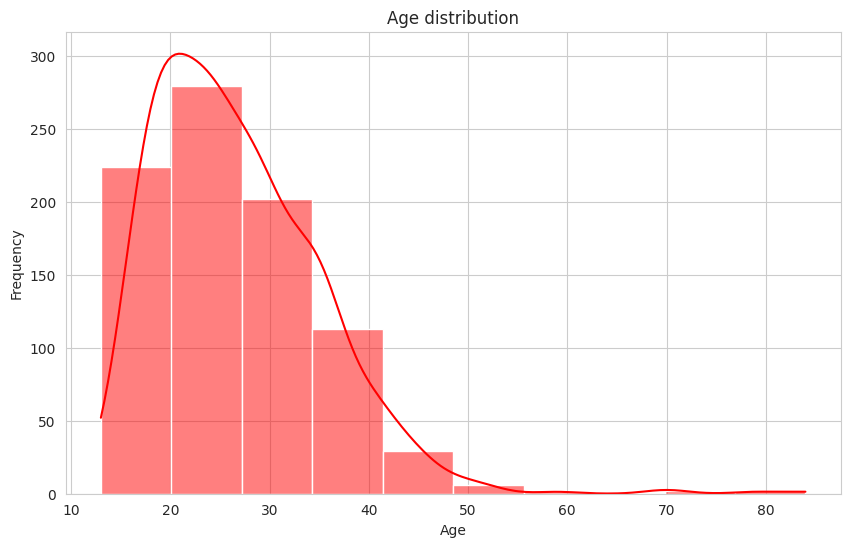

In [ ]:
sns.set_style('whitegrid')
plt.figure(figsize=(10,6))
sns.histplot(df['Age'],kde=True,color='red',bins=10)
plt.title('Age distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [ ]:
agepreg_bar = px.box(df.sort_values(by="Age",ascending=True), x="age_cat", y="Num of pregnancies",
                      color_discrete_sequence=["pink"], points="outliers",
                      category_orders=["Teenager", "Twenties", "Thirties", "Forties", "Fifties",
                                       "Seventy and over"])
agepreg_bar.update_xaxes(title="Age Category")
agepreg_bar.update_yaxes(title="Number of Pregnancies")
agepreg_bar.update_layout(title="Distribution of number of pregnancies per age group")
agepreg_bar.show()

In [ ]:
agenumsex_partn= px.box(df.sort_values(by="Age",ascending=True), x="age_cat", y="Number of sexual partners",
                      color_discrete_sequence=["orange"], points="outliers",
                      category_orders=["Teenager", "Twenties", "Thirties", "Forties", "Fifties",
                                       "Seventy and over"])
agenumsex_partn.update_xaxes(title="Age Category")
agenumsex_partn.update_yaxes(title="Number of Sexual Partners")
agenumsex_partn.update_layout(title="Distribution of number of sexual partners per age group")
agenumsex_partn.show()

From the scatterplot, it is seen that the number of sexual partners have remained consistent throught out differing age ranges

In [ ]:
agenumsex_partn = px.scatter(df, x="Age",
                                  y="Number of sexual partners",
                                  trendline="ols",
                                  opacity=0.5,
                                  color="Num of pregnancies",
                                  color_continuous_scale="rdbu",)
agenumsex_partn.update_layout(title="Age vs Number of Sexual Partners")
agenumsex_partn.show()

From the heatmap, we can see that there a correlation coefficent very close to 0, this indicates that, from the data, the number of sexual partners does not have any linear relationship with any of the respective diagnoses. However, we also visually knew that the number of sexual partners remained fairly consistent across age ranges and therefore there are more likely causes of HPV and Cervical Cancer than number of sexual partners with respect to the data.

In [ ]:
diag_num_partn_comp_cols = ['Dx:Cancer',
                                      'Dx:HPV',
                                      "Number of sexual partners",]
corr_matrix = df[diag_num_partn_comp_cols].corr()
print(corr_matrix)
diag_num_partn_heatmap = px.imshow(corr_matrix,
                              aspect="auto",
                              color_continuous_scale="gnbu",
                              text_auto=True)
diag_num_partn_heatmap.show()

                           Dx:Cancer    Dx:HPV  Number of sexual partners
Dx:Cancer                   1.000000  0.886508                   0.023699
Dx:HPV                      0.886508  1.000000                   0.028646
Number of sexual partners   0.023699  0.028646                   1.000000



Correlation of diagnoses Comparing the diagnoses, to see if there is any correlation among them. It's seen that a HPV diagnosis and Cervical Cancer Diagnosis have a correlation of approximately +0.89, this is indicative of a strong positive correlation. In some regard, it can be interprted as a diagnosis of HPV is likely to lead to a diagnosis of Cervical Cancer.




In [ ]:
diag_cols = ['Dx:Cancer',
                  'Dx:CIN',
                  'Dx:HPV']
diag_corr_matrix = df[diag_cols].corr()

diag_heatmap = px.imshow(diag_corr_matrix, aspect="auto", color_continuous_scale="tealgrn", text_auto=True)
diag_heatmap.show()

In [ ]:
fig = px.histogram(std_agg, x="age_cat", y=list(std_cols), barmode="group", histfunc="sum")
fig.update_layout(title="Sum of STD occurence across age categories")
fig.update_xaxes(title="Age Category")
fig.update_yaxes(title="Sum")
fig.show()

We see that the most amount of STD's garnered by any patient, is a total of 4. As from before, we also see that the majority of patients do not have any STD's and aren't diagnosed with cancer and/or HPV. However, there is a small amount of patients who have no STD and have Cervical Cancer and/or HPV. It should be noted that HPV infections can be sexually transmitted or non-sexually acquired.

In [ ]:
fig = px.histogram(df.query("total_tests>0").sort_values(by="total_tests", ascending=True),
                   x="age_cat",
                   facet_col="total_tests",
                   facet_row="Dx:Cancer",
                   color_discrete_sequence=["yellowgreen"],
                   opacity=0.9)
fig.update_layout(title="Count of women across age groups who have had one or more test")

fig.show()

In [ ]:
# Calculate the sample proportion for each age category
proportion_samples_df = df['age_cat'].value_counts(normalize=True).reset_index()
proportion_samples_df.columns = ['Category', 'Sample Proportion']

# Create a pie chart with the calculated proportions
fig = px.pie(proportion_samples_df,
             values='Sample Proportion',
             names='Category',
             title='Age Category Proportion of Women Sampled',
             color_discrete_sequence=px.colors.sequential.Plasma)

# Display the pie chart
fig.show()

# Display the DataFrame with proportions
proportion_samples_df

,Category,Sample Proportion
0,20's,0.459207
1,30's,0.256410
2,Teen,0.208625
3,40's,0.065268
4,50's,0.005828
5,70+,0.004662


Proportions of women who have Cervical Cancer / HPV
This represents the proportion of women by age category who were diagnosed with Cervical Cancer/ HPV. It is seen that women in their 30's have the most prevalance of Cervical Cancer and HPV, followed by women in their 20's.

It is also seen that of all the samples taken, approximately 26% are of women in their 30's. With respect to the women who have cervical cancer, approximately 44% of cases are women in their 30's, also, out of the women who have HPV, approximately 39% of women are in their 30's. This is contrasted with 45% of all samples being women in their 20's and only 28% of the women have cancer are in their 20's, HPV is more comparable at 33%

In [ ]:
# Group by age category and sum the values for IUD and Hormonal Contraceptives
df_hormonal_comparison = df.groupby("age_cat", as_index=False)[["IUD", "Hormonal Contraceptives"]].sum()
# Reshape the data to a long format for proper visualization in a grouped bar chart
df_melted = df_hormonal_comparison.melt(id_vars="age_cat",
                                        value_vars=["IUD", "Hormonal Contraceptives"],
                                        var_name="Contraceptive Type",
                                        value_name="Count")
# Create a grouped bar plot
fig = px.bar(df_melted,
             x="age_cat",
             y="Count",
             color="Contraceptive Type",
             barmode="group",
             color_discrete_sequence=["darkcyan", "mediumorchid"])

# Update axis titles for better clarity
fig.update_xaxes(title="Age Category")
fig.update_yaxes(title="Count")

# Update layout to enhance title and spacing
fig.update_layout(title="Usage of IUD and Hormonal Contraceptives by Age Category",
                  title_x=0.5,
                  bargap=0.2, # Adds some spacing between bars
                  legend_title_text="Contraceptive Type")

# Display the figure
fig.show()

In [ ]:
print("Original class distribution:")
print(df['Dx:Cancer'].value_counts())

Original class distribution:
Dx:Cancer
0    840
1     18
Name: count, dtype: int64


In [ ]:
# Calculate the proportion of each class to show percentages instead of counts
dx_cancer = px.histogram(df,
                         y="Dx:Cancer",
                         color="Dx:Cancer",
                         color_discrete_sequence=["crimson", "darkcyan"])

# Update layout to improve aesthetics and readability
dx_cancer.update_layout(
    title="Distribution of Cancer Diagnosis (Imbalanced Classes)",
    title_x=0.5,
    bargap=0.2,
    yaxis_title="Percentage",
    xaxis_title="Count",
    showlegend=False  # Hides legend since color represents the same variable
)

# Display the figure
dx_cancer.show()


We need to handle this imbalanced data either by undersampling or oversampling Here we will do Oversampling by SMOTE technique

In [ ]:
from imblearn.over_sampling import SMOTE

X = df.drop("Dx:Cancer", axis=1)
y = df["Dx:Cancer"]

# Identify and drop the original categorical columns before encoding
categorical_columns = ["age_cat"]  # categorical column to drop
X = X.drop(columns=categorical_columns)

# Convert categorical columns in X to numeric using one-hot encoding
X_numeric = pd.get_dummies(X, drop_first=True)

# Impute missing values using the mean for each column
mean_imputer = SimpleImputer(strategy='mean')
X_numeric_imputed = mean_imputer.fit_transform(X_numeric)
X_numeric_imputed = pd.DataFrame(X_numeric_imputed, columns=X_numeric.columns)

# Initialize SMOTE with a random state for reproducibility
smote = SMOTE(random_state=42)

# Fit SMOTE to your numeric data and resample, use the imputed data X_numeric_imputed
X_smote, y_smote = smote.fit_resample(X_numeric_imputed, y)

# Convert the resampled data back to DataFrame
df_smote = pd.DataFrame(X_smote, columns=X_numeric_imputed.columns)
df_smote['Dx:Cancer'] = y_smote

# Display the first few rows of the resampled DataFrame
print(df_smote.head())

    Age  Number of sexual partners  First sexual intercourse  \
0  18.0                        4.0                      15.0   
1  15.0                        1.0                      14.0   
2  34.0                        1.0                      16.0   
3  52.0                        5.0                      16.0   
4  46.0                        3.0                      21.0   

   Num of pregnancies  Smokes  Smokes (years)  Smokes (packs/year)  \
0                 1.0     0.0             0.0                  0.0   
1                 1.0     0.0             0.0                  0.0   
2                 1.0     0.0             0.0                  0.0   
3                 4.0     1.0            37.0                 37.0   
4                 4.0     0.0             0.0                  0.0   

   Hormonal Contraceptives  Hormonal Contraceptives (years)  IUD  ...  Dx:CIN  \
0                      0.0                              0.0  0.0  ...     0.0   
1                      0.0      

In [ ]:
print("Resampled class distribution:")
print(pd.Series(y_smote).value_counts())

Resampled class distribution:
Dx:Cancer
0    840
1    840
Name: count, dtype: int64


In [ ]:
# Calculate the proportion of each class to show percentages instead of counts
dx_cancer = px.histogram(df_smote,
                         y="Dx:Cancer",
                         color="Dx:Cancer",
                         color_discrete_sequence=["crimson", "darkcyan"])

# Update layout to improve aesthetics and readability
dx_cancer.update_layout(
    title="Distribution of Cancer Diagnosis (Balanced Classes)",
    title_x=0.5,
    bargap=0.2,
    yaxis_title="Percentage",
    xaxis_title="Count",
    showlegend=False  # Hides legend since color represents the same variable
)

# Display the figure
dx_cancer.show()

In [ ]:
df_smote.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1680 entries, 0 to 1679
Data columns (total 38 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 1680 non-null   float64
 1   Number of sexual partners           1680 non-null   float64
 2   First sexual intercourse            1680 non-null   float64
 3   Num of pregnancies                  1680 non-null   float64
 4   Smokes                              1680 non-null   float64
 5   Smokes (years)                      1680 non-null   float64
 6   Smokes (packs/year)                 1680 non-null   float64
 7   Hormonal Contraceptives             1680 non-null   float64
 8   Hormonal Contraceptives (years)     1680 non-null   float64
 9   IUD                                 1680 non-null   float64
 10  IUD (years)                         1680 non-null   float64
 11  STDs                                1680 no

Data Checks to perform
Check Missing values(done already)
Check Duplicates
Check data type(done already)
Check the number of unique values of each column
Check statistics of data set
Check columns with categorical data (done already)

In [ ]:
df_smote.isna().sum()

,0
Age,0
Number of sexual partners,0
First sexual intercourse,0
Num of pregnancies,0
Smokes,0
Smokes (years),0
Smokes (packs/year),0
Hormonal Contraceptives,0
Hormonal Contraceptives (years),0
IUD,0


<Axes: >

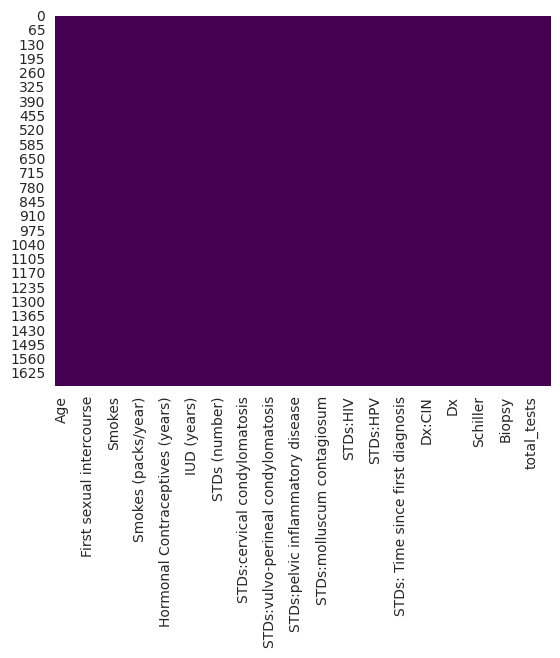

In [ ]:
#plot heatmap of missing values
sns.heatmap(df_smote.isnull(), cmap="viridis", cbar=False)


In [ ]:
df_smote['Dx:Cancer'].unique()

array([0, 1])

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

In [ ]:
target_column = 'Dx:Cancer'

# Separate features and target
X = df_smote.drop(columns=[target_column])
y = df_smote[target_column]

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform only the features
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Combine the scaled features and target back into a single DataFrame
df_scaled = pd.concat([X_scaled, y.reset_index(drop=True)], axis=1)

In [ ]:
print("Original DataFrame:")
print(df.head)

print("\nDataFrame after SMOTE:")
print(df_smote.head)

print("\nStandardized DataFrame:")
print(df_scaled.head)

Original DataFrame:
<bound method NDFrame.head of      Age  Number of sexual partners  First sexual intercourse  \
0     18                          4                        15   
1     15                          1                        14   
2     34                          1                        16   
3     52                          5                        16   
4     46                          3                        21   
..   ...                        ...                       ...   
853   34                          3                        18   
854   32                          2                        19   
855   25                          2                        17   
856   33                          2                        24   
857   29                          2                        20   

     Num of pregnancies  Smokes  Smokes (years)  Smokes (packs/year)  \
0                     1       0             0.0                  0.0   
1                     1  

In [ ]:
# Check Duplicates
df_scaled.duplicated().sum()

25

In [ ]:
df_scaled = df_scaled.drop_duplicates()

In [ ]:
df_scaled.duplicated().sum()

0

In [ ]:
df_scaled.head(10)

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy,total_std,total_tests,Dx:Cancer
0,-1.427807,0.937093,-1.116509,-1.193740,-0.380169,-0.307484,-0.214475,-1.388089,-0.703652,-0.608757,...,-0.073389,-0.941425,-0.892478,-0.446271,-0.650882,-0.477391,-0.562951,-0.277056,-0.692902,0
1,-1.791175,-1.206162,-1.536017,-1.193740,-0.380169,-0.307484,-0.214475,-1.388089,-0.703652,-0.608757,...,-0.073389,-0.941425,-0.892478,-0.446271,-0.650882,-0.477391,-0.562951,-0.277056,-0.692902,0
2,0.510153,-1.206162,-0.697001,-1.193740,-0.380169,-0.307484,-0.214475,-1.388089,-0.703652,-0.608757,...,-0.073389,-0.941425,-0.892478,-0.446271,-0.650882,-0.477391,-0.562951,-0.277056,-0.692902,0
3,2.690359,1.651512,-0.697001,1.237791,2.944550,6.750006,8.160279,0.834569,0.105709,-0.608757,...,-0.073389,1.126139,-0.892478,-0.446271,-0.650882,-0.477391,-0.562951,-0.277056,-0.692902,1
4,1.963624,0.222675,1.400539,1.237791,-0.380169,-0.307484,-0.214475,0.834569,3.343153,-0.608757,...,-0.073389,-0.941425,-0.892478,-0.446271,-0.650882,-0.477391,-0.562951,-0.277056,-0.692902,0
5,1.479134,0.222675,2.239554,-0.383230,-0.380169,-0.307484,-0.214475,-1.388089,-0.703652,-0.608757,...,-0.073389,-0.941425,-0.892478,-0.446271,-0.650882,-0.477391,-0.562951,-0.277056,-0.692902,0
6,2.569237,0.222675,-0.277493,2.858811,2.944550,6.177777,0.555097,-1.388089,-0.703652,1.996369,...,-0.073389,-0.941425,-0.892478,3.177126,2.043836,-0.477391,2.394438,-0.277056,2.256248,0
7,-0.458827,-1.206162,3.498078,0.427281,-0.380169,-0.307484,-0.214475,0.834569,-0.164078,1.996369,...,-0.073389,-0.941425,-0.892478,-0.446271,-0.650882,-0.477391,-0.562951,-0.277056,-0.692902,0
8,1.842501,-1.206162,0.981031,2.048301,-0.380169,-0.307484,-0.214475,-1.388089,-0.703652,-0.608757,...,-0.073389,1.126139,1.202736,-0.446271,-0.650882,-0.477391,-0.562951,-0.277056,-0.692902,1
9,1.721379,0.222675,-1.116509,-0.383230,2.944550,-0.065818,0.419290,-1.388089,-0.703652,-0.608757,...,-0.073389,-0.941425,-0.892478,-0.446271,-0.650882,-0.477391,-0.562951,-0.277056,-0.692902,0


In [ ]:
# Checking the number of uniques values of each columns
df_scaled.nunique()

,0
Age,803
Number of sexual partners,552
First sexual intercourse,678
Num of pregnancies,689
Smokes,110
Smokes (years),276
Smokes (packs/year),308
Hormonal Contraceptives,327
Hormonal Contraceptives (years),754
IUD,315


In [ ]:
## Check the statistics of the dataset
df_scaled.describe()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy,total_std,total_tests,Dx:Cancer
count,1655.000000,1655.000000,1655.000000,1655.000000,1655.000000,1655.000000,1655.000000,1655.000000,1655.000000,1655.000000,...,1655.000000,1655.000000,1655.000000,1655.000000,1655.000000,1655.000000,1655.000000,1655.000000,1655.000000,1655.000000
mean,0.018055,0.010882,0.010275,0.013135,0.005743,0.004645,0.003240,0.015596,0.006982,0.009196,...,0.001109,0.014221,0.013482,0.006741,0.008204,0.005286,0.006717,0.004185,0.008685,0.507553
std,0.993348,1.000879,0.999045,1.000073,1.006728,1.007109,1.007479,0.994650,1.005288,1.005004,...,1.007788,1.001060,1.001748,1.006312,1.003484,1.003965,1.003798,1.007245,1.002796,0.500094
min,-2.033420,-1.206162,-3.214049,-2.004250,-0.380169,-0.307484,-0.214475,-1.388089,-0.703652,-0.608757,...,-0.073389,-0.941425,-0.892478,-0.446271,-0.650882,-0.477391,-0.562951,-0.277056,-0.692902,0.000000
25%,-0.701072,-0.491743,-0.697001,-0.430497,-0.380169,-0.307484,-0.214475,-1.388089,-0.682069,-0.608757,...,-0.073389,-0.941425,-0.892478,-0.446271,-0.650882,-0.477391,-0.562951,-0.277056,-0.692902,0.000000
50%,-0.055925,-0.051636,0.142015,-0.341034,-0.380169,-0.307484,-0.214475,0.834569,-0.433865,-0.608757,...,-0.073389,-0.856809,-0.892478,-0.446271,-0.650882,-0.477391,-0.562951,-0.277056,-0.692902,1.000000
75%,0.631276,0.222675,0.561523,0.427281,-0.380169,-0.307484,-0.214475,0.834569,0.146393,0.592687,...,-0.073389,1.126139,1.202736,-0.446271,0.635241,-0.477391,0.201315,-0.277056,0.461395,1.000000
max,6.566280,18.083136,6.015126,6.911363,2.944550,6.750006,8.160279,0.834569,7.389959,1.996369,...,13.625956,1.126139,1.202736,3.177126,2.043836,2.709650,2.394438,9.585629,3.239297,1.000000


Insights or Observation

In [ ]:
y = df_scaled["Dx:Cancer"]

In [ ]:
print("Shape of df_scaled:", df_scaled.shape)
print("Shape of y:", y.shape)

Shape of df_scaled: (1655, 38)
Shape of y: (1655,)


In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit

# Separate features and target
X = df_scaled.drop("Dx:Cancer", axis=1)
y = df_scaled["Dx:Cancer"]

# Perform the split
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, test_idx in split.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()

# Drop unwanted columns from the train and test sets
cols_to_drop = ["total_std", "total_tests"]
X_train.drop(cols_to_drop, axis=1, inplace=True)
X_test.drop(cols_to_drop, axis=1, inplace=True)

PCA Visualization

In [ ]:
from sklearn.decomposition import PCA
import plotly.express as px
import plotly.graph_objects as go
pca = PCA(n_components=0.99)
XT = pca.fit_transform(X_train)

# Plotting the explained variance ratio for each component with enhanced formatting
dimensions = px.bar(
    x=range(pca.n_components_),
    y=pca.explained_variance_ratio_,
    color_discrete_sequence=["#2c3e50"],
    labels={"x": "PCA Feature", "y": "Explained Variance"},
    title="Explained Variance Ratio by PCA Components"
)
dimensions.update_layout(
    template="plotly_dark",
    title_font=dict(size=20, family='Arial', color='white'),
    xaxis=dict(
        tickmode='linear',
        tick0=0,
        dtick=1
    ),
    yaxis=dict(
        gridcolor='gray'
    )
)
dimensions.show()

# Calculating cumulative explained variance
exp_var_cumul = np.cumsum(pca.explained_variance_ratio_)

# Plotting cumulative explained variance with enhanced formatting
explained_variance = px.area(
    x=range(1, exp_var_cumul.shape[0] + 1),
    y=exp_var_cumul,
    labels={"x": "# Components", "y": "Cumulative Explained Variance"},
    title="Cumulative Explained Variance by PCA Components",
    color_discrete_sequence=["#3498db"]
)
explained_variance.update_layout(
    template="plotly_dark",
    title_font=dict(size=20, family='Arial', color='white'),
    xaxis=dict(
        tickmode='linear',
        tick0=1,
        dtick=1
    ),
    yaxis=dict(
        gridcolor='gray'
    )
)
explained_variance.add_trace(go.Scatter(
    x=list(range(1, exp_var_cumul.shape[0] + 1)),
    y=exp_var_cumul,
    mode='lines+markers',
    line=dict(color='white', width=2),
    marker=dict(size=6, color='white'),
    showlegend=False
))
explained_variance.show()

This trend indicates that the first few components are capturing the most critical features or patterns in the data. Components beyond the 10th or 15th contribute very little individually, suggesting that these later components capture minor variations or noise in the data. We choose the top 15 components to train our model

Modelling

In [ ]:
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report, confusion_matrix
# Make a pipeline with SVM classifier
pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ("pca", PCA(n_components=13)),
    ('scaler', StandardScaler()),
    ('svm', SVC())
])
# Define hyperparameter grid
param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 0.001, 0.01, 0.1],
    'svm__kernel': ['linear', 'rbf', 'poly']
}

# Perform grid search with cross-validation
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Ensure y is a discrete variable, for example by converting it to integers
#y = y.astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the model
grid_search.fit(X_train, y_train)
# Output the best hyperparameters
print("Best Hyperparameters:", grid_search.best_params_)

# Evaluate the best model on the test set
test_score = grid_search.score(X_test, y_test)
print("Test Accuracy:", test_score)
# Make predictions on the test set
y_pred = grid_search.predict(X_test)

# You can now calculate additional metrics if needed, e.g., confusion matrix, classification report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Best Hyperparameters: {'svm__C': 100, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Test Accuracy: 0.9969788519637462
[[172   1]
 [  0 158]]
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       173
           1       0.99      1.00      1.00       158

    accuracy                           1.00       331
   macro avg       1.00      1.00      1.00       331
weighted avg       1.00      1.00      1.00       331



Finalize the Model with Best Hyperparameters:

In [ ]:
# Retrieve the best hyperparameters from GridSearchCV
best_params = grid_search.best_params_

# Create a new pipeline using the best hyperparameters
final_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ("pca", PCA(n_components=13)),
    ('scaler', StandardScaler()),
    ('svm', SVC(C=best_params['svm__C'],
                gamma=best_params['svm__gamma'],
                kernel=best_params['svm__kernel'],
                class_weight='balanced',
                probability=True))   # Adding class_weight to handle imbalanced classes
])

# Train the final model on the entire training dataset
final_pipeline.fit(X_train, y_train)

# Get decision function scores
decision_scores = final_pipeline.decision_function(X_train)

# Set a custom threshold
threshold =0.1  # Example threshold, adjust as needed
predicted_probs = (decision_scores > threshold).astype(int)

# Calculate recall to see the effect of threshold
recall = recall_score(y_train, predicted_probs,average='macro')
print(f'Recall with custom threshold: {recall:.4f}')

Recall with custom threshold: 1.0000


In [ ]:
# Evaluate the final model on the test set
final_test_score = final_pipeline.score(X_test, y_test)
print("Final Test Accuracy:", final_test_score)

# Make predictions on the test set
y_final_pred = final_pipeline.predict(X_test)

Final Test Accuracy: 0.9969788519637462


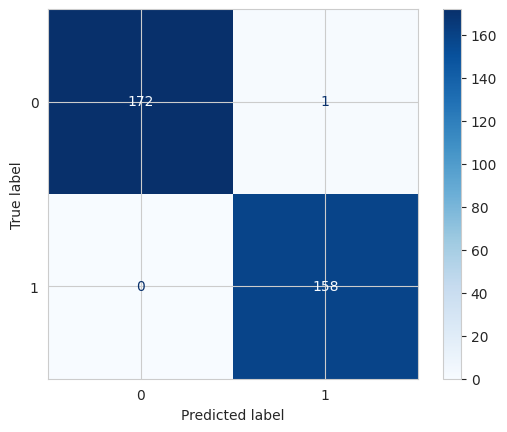

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_final_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=final_pipeline.classes_)
disp.plot(cmap='Blues')
plt.show()

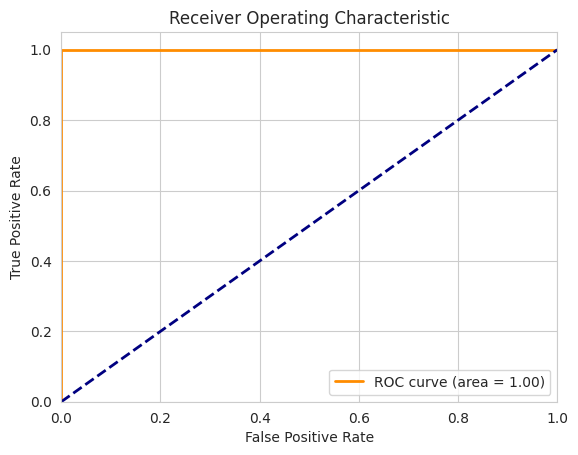

In [ ]:
from sklearn.metrics import roc_curve, auc

# Assuming y_test contains labels -1 and 1, convert -1 to 0
y_test_modified = np.array([0 if y == -1 else y for y in y_test])

# Compute the decision function or probability estimates
y_score = final_pipeline.predict_proba(X_test)[:, 1]

# Compute ROC curve and ROC area for the modified y_test
fpr, tpr, thresholds = roc_curve(y_test_modified, y_score)
roc_auc = auc(fpr, tpr)

# Plotting the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

Perfect Classifier (AUC = 1.00): The curve touches the top left corner (TPR=1, FPR=0) immediately and stays at TPR=1 across all values of FPR. This is a sign of a perfect classifier, meaning that the model is classifying all positives and negatives correctly with no errors.

AUC = 1.00: The Area Under the Curve (AUC) is 1.00, which confirms that the model perfectly distinguishes between the positive and negative classes in this dataset.

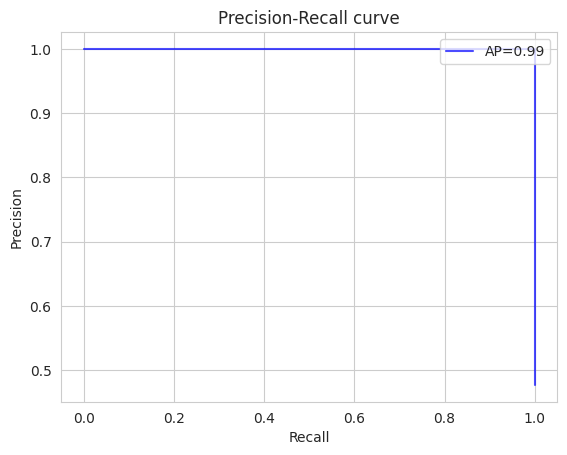

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Map -1 in y_test to 1 (or you could map 0 to 1 and -1 to 0)
y_test_modified = [1 if y == -1 else y for y in y_test]

# Compute Precision-Recall curve and average precision using modified y_test
precision, recall, _ = precision_recall_curve(y_test_modified, final_pipeline.decision_function(X_test))
average_precision = average_precision_score(y_test_modified, y_final_pred)

# Plot Precision-Recall curve
plt.figure()
plt.step(recall, precision, where='post', color='b', alpha=0.7, label=f'AP={average_precision:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curve')
plt.legend(loc='upper right')
plt.show()


Perfect Classifier (AP = 1.00):
The curve is very close to the top-right corner, which indicates that the model is performing exceptionally well with both high precision and recall. The value AP=0.99 indicates that the average precision, which is a summary measure of the precision-recall curve, is very high. An AP of 1 would be perfect, and an AP of 0.99 suggests that the model is extremely good at distinguishing between classes.